In [1]:
import pickle
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import glob
import xarray as xr
plt.rcParams['text.usetex'] = True

In [2]:
path = '/pscratch/sd/m/mckenna/dharma_post/'
bulk_file = 'cntl_bulk_ice_ABIFM_sounding_time_series.pkl'
bulk_sip_file = 'sip_bulk_ice_ABIFM_sounding_time_series.pkl'
bulk_sip_10x_file = 'sip_10x_bulk_ice_ABIFM_sounding_time_series.pkl'
bin_file = 'cntl_bin_ice_sounding_time_series.pkl'
bin_sip_file = 'sip_bin_ice_sounding_time_series.pkl'
bin_sip_10x_file = 'sip_10x_bin_ice_sounding_time_series.pkl'

In [3]:
with open(path+bulk_file, 'rb') as file:
    bulk_dict = pickle.load(file)
with open(path+bulk_sip_file, 'rb') as file:
    bulk_sip_dict = pickle.load(file)
with open(path+bulk_sip_10x_file, 'rb') as file:
    bulk_sip_10x_dict = pickle.load(file)
with open(path+bin_file, 'rb') as file:
    bin_dict = pickle.load(file)
with open(path+bin_sip_file, 'rb') as file:
    bin_sip_dict = pickle.load(file)
with open(path+bin_sip_10x_file, 'rb') as file:
    bin_sip_10x_dict = pickle.load(file)

In [4]:
def running_mean(arr, window):
    kernel = np.ones(window) / window
    return np.convolve(arr, kernel, mode='same')

running_mean_window = 20

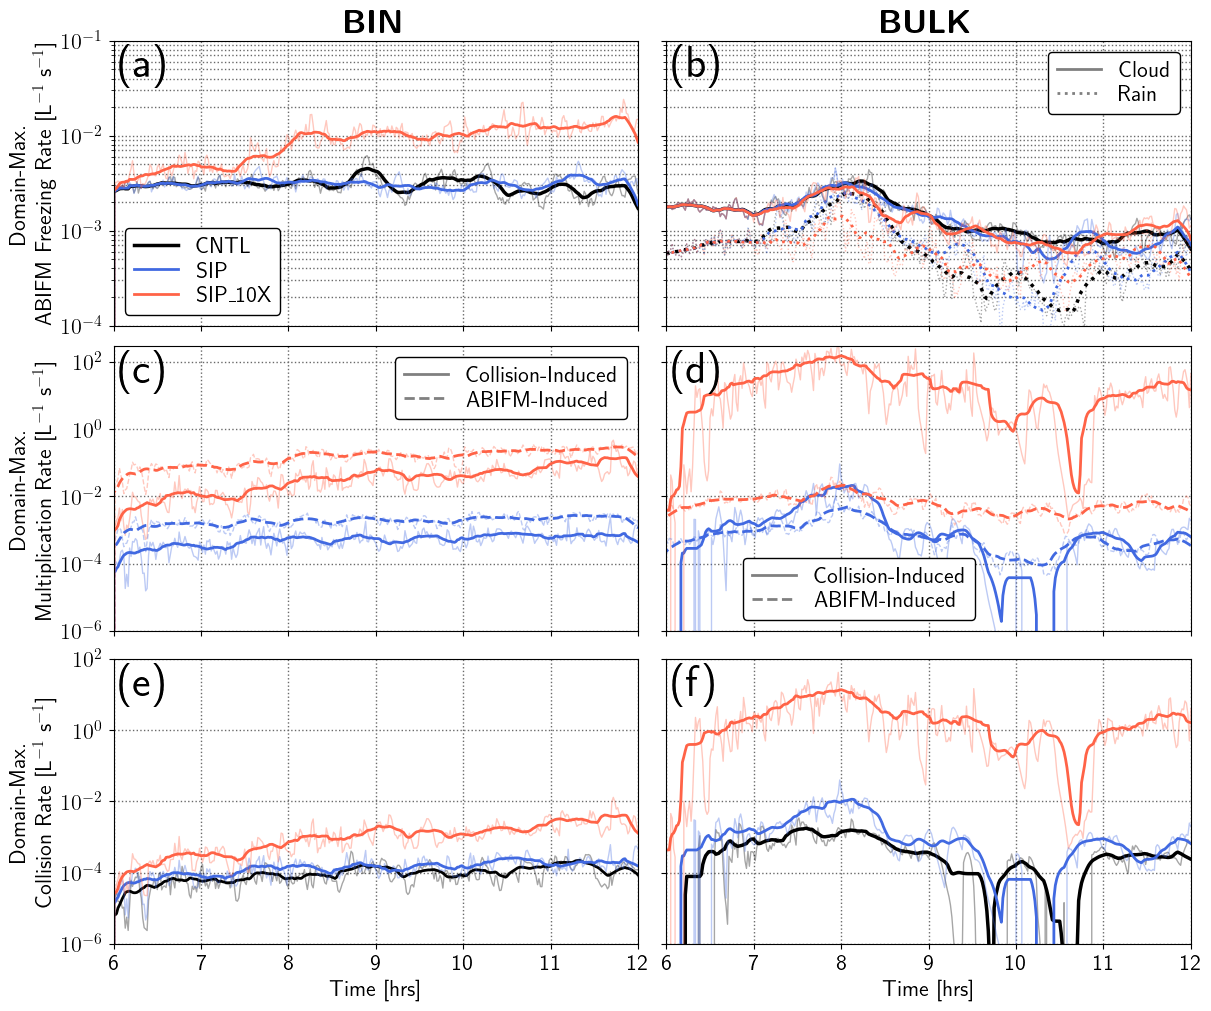

In [7]:
fig = plt.figure(figsize=(12,10),constrained_layout=True)
ax1 = fig.add_subplot(321)
ax2 = fig.add_subplot(322)
ax3 = fig.add_subplot(323)
ax4 = fig.add_subplot(324)
ax5 = fig.add_subplot(325)
ax6 = fig.add_subplot(326)
axlist = [ax1,ax2,ax3,ax4,ax5,ax6]
Fontsize=16
for ax in axlist:
    ax.grid(which='both',ls='dotted',lw=1,c='dimgrey')
    ax.tick_params(labelsize=Fontsize)
    ax.set_xlim(6,12)
    ax.set_xticks(np.arange(6,13,1))
    ax.set_xticklabels([])
    ax.set_yscale('log')

ax5.set_xlabel('Time [hrs]',fontsize=Fontsize)
ax6.set_xlabel('Time [hrs]',fontsize=Fontsize)
ax5.set_xticklabels(['6','7','8','9','10','11','12'])
ax6.set_xticklabels(['6','7','8','9','10','11','12'])

ax3.set_ylabel('Domain-Max.\nMultiplication Rate [L$^{-1}$ s$^{-1}$]',fontsize=Fontsize)
ax5.set_ylabel('Domain-Max.\nCollision Rate [L$^{-1}$ s$^{-1}$]',fontsize=Fontsize)

#============================================
# ABIFM Freezing Rate
#============================================
ax1.set_ylabel('Domain-Max.\nABIFM Freezing Rate [L$^{-1}$ s$^{-1}$]',fontsize=Fontsize)


# Bin
ax1.plot(bin_dict['time']/3600.,bin_dict['max_in_imm']*1.e3,alpha=0.35,lw=1,c='k')
ax1.plot(bin_dict['time']/3600.,running_mean(bin_dict['max_in_imm']*1.e3,running_mean_window),lw=2.5,c='k',label='CNTL')
ax1.plot(bin_sip_dict['time']/3600.,bin_sip_dict['max_in_imm']*1.e3,alpha=0.35,lw=1,c='royalblue')
ax1.plot(bin_sip_dict['time']/3600.,running_mean(bin_sip_dict['max_in_imm']*1.e3,running_mean_window),lw=2,c='royalblue',label='SIP')
ax1.plot(bin_sip_10x_dict['time']/3600.,bin_sip_10x_dict['max_in_imm']*1.e3,alpha=0.35,lw=1,c='tomato')
ax1.plot(bin_sip_10x_dict['time']/3600.,running_mean(bin_sip_10x_dict['max_in_imm']*1.e3,running_mean_window),lw=2,c='tomato',label='SIP_10X')

#ax1.plot(bin_dict_v2['time']/3600.,bin_dict_v2['max_in_imm']*1.e3,alpha=0.35,lw=1,c='k')
#ax1.plot(bin_dict_v2['time']/3600.,running_mean(bin_dict_v2['max_in_imm']*1.e3,running_mean_window),lw=2.5,c='k',label='CNTL')
#ax1.plot(bin_sip_dict_v2['time']/3600.,bin_sip_dict_v2['max_in_imm']*1.e3,alpha=0.35,lw=1,c='royalblue')
#ax1.plot(bin_sip_dict_v2['time']/3600.,running_mean(bin_sip_dict_v2['max_in_imm']*1.e3,running_mean_window),lw=2,c='royalblue',label='SIP')
#ax1.plot(bin_sip_10x_dict_v2['time']/3600.,bin_sip_10x_dict_v2['max_in_imm']*1.e3,alpha=0.35,lw=1,c='tomato')
#ax1.plot(bin_sip_10x_dict_v2['time']/3600.,running_mean(bin_sip_10x_dict_v2['max_in_imm']*1.e3,running_mean_window),lw=2,c='tomato',label='SIP_10X')

# Bulk
dum_ls = 'dotted'
ax2.plot(bulk_dict['time']/3600.,bulk_dict['max_in_imm_c']*1.e3,alpha=0.35,lw=1,c='k')
ax2.plot(bulk_dict['time']/3600.,running_mean(bulk_dict['max_in_imm_c']*1.e3,running_mean_window),lw=2.5,c='k')
ax2.plot(bulk_dict['time']/3600.,bulk_dict['max_in_imm_r']*1.e3,alpha=0.35,lw=1,c='k',ls=dum_ls)
ax2.plot(bulk_dict['time']/3600.,running_mean(bulk_dict['max_in_imm_r']*1.e3,running_mean_window),lw=2.5,c='k',ls=dum_ls)

ax2.plot(bulk_sip_dict['time']/3600.,bulk_sip_dict['max_in_imm_c']*1.e3,alpha=0.35,lw=1,c='royalblue')
ax2.plot(bulk_sip_dict['time']/3600.,running_mean(bulk_sip_dict['max_in_imm_c']*1.e3,running_mean_window),lw=2,c='royalblue')
ax2.plot(bulk_sip_dict['time']/3600.,bulk_sip_dict['max_in_imm_r']*1.e3,alpha=0.35,lw=1,c='royalblue',ls=dum_ls)
ax2.plot(bulk_sip_dict['time']/3600.,running_mean(bulk_sip_dict['max_in_imm_r']*1.e3,running_mean_window),lw=2,c='royalblue',ls=dum_ls)

ax2.plot(bulk_sip_10x_dict['time']/3600.,bulk_sip_10x_dict['max_in_imm_c']*1.e3,alpha=0.35,lw=1,c='tomato')
ax2.plot(bulk_sip_10x_dict['time']/3600.,running_mean(bulk_sip_10x_dict['max_in_imm_c']*1.e3,running_mean_window),lw=2,c='tomato')
ax2.plot(bulk_sip_10x_dict['time']/3600.,bulk_sip_10x_dict['max_in_imm_r']*1.e3,alpha=0.35,lw=1,c='tomato',ls=dum_ls)
ax2.plot(bulk_sip_10x_dict['time']/3600.,running_mean(bulk_sip_10x_dict['max_in_imm_r']*1.e3,running_mean_window),lw=2,c='tomato',ls=dum_ls)

ax1.set_ylim(1.e-4,1.e-1)
ax2.set_ylim(1.e-4,1.e-1)
ax1.legend(loc='lower left',fontsize=Fontsize*1,framealpha=1,edgecolor='k',labelspacing=0.2)

legend_elements = [
    Line2D([0], [0], color='gray', lw=2.0, ls='solid', label=r'Cloud'),
    Line2D([0], [0], color='gray', lw=2.0, ls=dum_ls, label=r'Rain')
]
ax2.legend(handles=legend_elements, fontsize=Fontsize, loc='upper right',labelspacing=0.2,framealpha=1,edgecolor='k')

ax1.set_yticks(10.**np.arange(-4,0,1))
ax2.set_yticks(10.**np.arange(-4,0,1))
ax2.set_yticklabels([])

#============================================
# Multiplication Rate
#============================================
ax3.plot(bin_sip_dict['time']/3600.,bin_sip_dict['max_sh_coag']*1.e3,alpha=0.35,lw=1,c='royalblue')
ax3.plot(bin_sip_dict['time']/3600.,running_mean(bin_sip_dict['max_sh_coag']*1.e3,running_mean_window),lw=2,c='royalblue')
ax3.plot(bin_sip_10x_dict['time']/3600.,bin_sip_10x_dict['max_sh_coag']*1.e3,alpha=0.35,lw=1,c='tomato')
ax3.plot(bin_sip_10x_dict['time']/3600.,running_mean(bin_sip_10x_dict['max_sh_coag']*1.e3,running_mean_window),lw=2,c='tomato')

ax3.plot(bin_sip_dict['time']/3600.,bin_sip_dict['max_sh_in']*1.e3,alpha=0.35,lw=1,c='royalblue',ls='dashed')
ax3.plot(bin_sip_dict['time']/3600.,running_mean(bin_sip_dict['max_sh_in']*1.e3,running_mean_window),lw=2,c='royalblue',ls='dashed')
ax3.plot(bin_sip_10x_dict['time']/3600.,bin_sip_10x_dict['max_sh_in']*1.e3,alpha=0.35,lw=1,c='tomato',ls='dashed')
ax3.plot(bin_sip_10x_dict['time']/3600.,running_mean(bin_sip_10x_dict['max_sh_in']*1.e3,running_mean_window),lw=2,c='tomato',ls='dashed')

#ax3.plot(bin_sip_dict_v2['time']/3600.,bin_sip_dict_v2['max_sh_coag']*1.e3,alpha=0.35,lw=1,c='royalblue')
#ax3.plot(bin_sip_dict_v2['time']/3600.,running_mean(bin_sip_dict_v2['max_sh_coag']*1.e3,running_mean_window),lw=2,c='royalblue')
#ax3.plot(bin_sip_10x_dict_v2['time']/3600.,bin_sip_10x_dict_v2['max_sh_coag']*1.e3,alpha=0.35,lw=1,c='tomato')
#ax3.plot(bin_sip_10x_dict_v2['time']/3600.,running_mean(bin_sip_10x_dict_v2['max_sh_coag']*1.e3,running_mean_window),lw=2,c='tomato')

#ax3.plot(bin_sip_dict_v2['time']/3600.,bin_sip_dict_v2['max_sh_in']*1.e3,alpha=0.35,lw=1,c='royalblue',ls='dashed')
#ax3.plot(bin_sip_dict_v2['time']/3600.,running_mean(bin_sip_dict_v2['max_sh_in']*1.e3,running_mean_window),lw=2,c='royalblue',ls='dashed')
#ax3.plot(bin_sip_10x_dict_v2['time']/3600.,bin_sip_10x_dict_v2['max_sh_in']*1.e3,alpha=0.35,lw=1,c='tomato',ls='dashed')
#ax3.plot(bin_sip_10x_dict_v2['time']/3600.,running_mean(bin_sip_10x_dict_v2['max_sh_in']*1.e3,running_mean_window),lw=2,c='tomato',ls='dashed')


ax4.plot(bulk_sip_dict['time']/3600.,bulk_sip_dict['max_sh_coag']*1.e3,alpha=0.35,lw=1,c='royalblue')
ax4.plot(bulk_sip_dict['time']/3600.,running_mean(bulk_sip_dict['max_sh_coag']*1.e3,running_mean_window),lw=2,c='royalblue')
ax4.plot(bulk_sip_10x_dict['time']/3600.,bulk_sip_10x_dict['max_sh_coag']*1.e3,alpha=0.35,lw=1,c='tomato')
ax4.plot(bulk_sip_10x_dict['time']/3600.,running_mean(bulk_sip_10x_dict['max_sh_coag']*1.e3,running_mean_window),lw=2,c='tomato')

ax4.plot(bulk_sip_dict['time']/3600.,bulk_sip_dict['max_sh_in_r']*1.e3,alpha=0.35,lw=1,c='royalblue',ls='dashed')
ax4.plot(bulk_sip_dict['time']/3600.,running_mean(bulk_sip_dict['max_sh_in_r']*1.e3,running_mean_window),lw=2,c='royalblue',ls='dashed')
ax4.plot(bulk_sip_10x_dict['time']/3600.,bulk_sip_10x_dict['max_sh_in_r']*1.e3,alpha=0.35,lw=1,c='tomato',ls='dashed')
ax4.plot(bulk_sip_10x_dict['time']/3600.,running_mean(bulk_sip_10x_dict['max_sh_in_r']*1.e3,running_mean_window),lw=2,c='tomato',ls='dashed')

ax3.set_ylim(1.e-6,3.e2)
ax4.set_ylim(1.e-6,3.e2)


legend_elements = [
    Line2D([0], [0], color='gray', lw=2.0, ls='solid', label=r'Collision-Induced'),
    Line2D([0], [0], color='gray', lw=2.0, ls='dashed', label=r'ABIFM-Induced')
]
ax3.legend(handles=legend_elements, fontsize=Fontsize, loc='upper right',labelspacing=0.2,framealpha=1,edgecolor='k')
ax4.legend(handles=legend_elements, fontsize=Fontsize, loc='lower left',labelspacing=0.2,framealpha=1,edgecolor='k',bbox_to_anchor=(0.125,0.))

ax3.set_yticks(10.**np.arange(-6,2.3,2))
ax4.set_yticks(10.**np.arange(-6,2.3,2))
ax4.set_yticklabels([])

#============================================
# Collision Rate
#============================================
ax5.plot(bin_dict['time']/3600.,bin_dict['max_sh_coag_raw']*1.e3,alpha=0.35,lw=1,c='k')
ax5.plot(bin_dict['time']/3600.,running_mean(bin_dict['max_sh_coag_raw']*1.e3,running_mean_window),lw=2,c='k',label='BIN CNTL')
ax5.plot(bin_sip_dict['time']/3600.,bin_sip_dict['max_sh_coag_raw']*1.e3,alpha=0.35,lw=1,c='royalblue')
ax5.plot(bin_sip_dict['time']/3600.,running_mean(bin_sip_dict['max_sh_coag_raw']*1.e3,running_mean_window),lw=2,c='royalblue',label='BIN SIP')
ax5.plot(bin_sip_10x_dict['time']/3600.,bin_sip_10x_dict['max_sh_coag_raw']*1.e3,alpha=0.35,lw=1,c='tomato')
ax5.plot(bin_sip_10x_dict['time']/3600.,running_mean(bin_sip_10x_dict['max_sh_coag_raw']*1.e3,running_mean_window),lw=2,c='tomato',label='BIN SIP 10X')

ax6.plot(bulk_dict['time']/3600.,bulk_dict['max_sh_coag_raw']*1.e3,alpha=0.35,lw=1,c='k')
ax6.plot(bulk_dict['time']/3600.,running_mean(bulk_dict['max_sh_coag_raw']*1.e3,running_mean_window),lw=2.5,c='k')
ax6.plot(bulk_sip_dict['time']/3600.,bulk_sip_dict['max_sh_coag_raw']*1.e3,alpha=0.35,lw=1,c='royalblue')
ax6.plot(bulk_sip_dict['time']/3600.,running_mean(bulk_sip_dict['max_sh_coag_raw']*1.e3,running_mean_window),lw=2,c='royalblue')
ax6.plot(bulk_sip_10x_dict['time']/3600.,bulk_sip_10x_dict['max_sh_coag_raw']*1.e3,alpha=0.35,lw=1,c='tomato')
ax6.plot(bulk_sip_10x_dict['time']/3600.,running_mean(bulk_sip_10x_dict['max_sh_coag_raw']*1.e3,running_mean_window),lw=2,c='tomato')

ax5.set_ylim(1.e-6,1.e2)
ax6.set_ylim(1.e-6,1.e2)

ax5.set_yticks(10.**np.arange(-6,3,2))
ax6.set_yticks(10.**np.arange(-6,3,2))
ax6.set_yticklabels([])


labs = [r'\textbf{(a)}',\
        r'\textbf{(b)}',\
        r'\textbf{(c)}',\
        r'\textbf{(d)}',\
        r'\textbf{(e)}',\
        r'\textbf{(f)}']
labs = ['(a)','(b)','(c)','(d)','(e)','(f)']
for ii,ax in enumerate(axlist):
    ax.text(0.01,0.99,labs[ii],fontsize=Fontsize*2.,transform=ax.transAxes,ha='left',va='top')


ax1.set_title(r'\textbf{BIN}',fontsize=Fontsize*1.5)
ax2.set_title(r'\textbf{BULK}',fontsize=Fontsize*1.5)

plt.show()
plt.close()

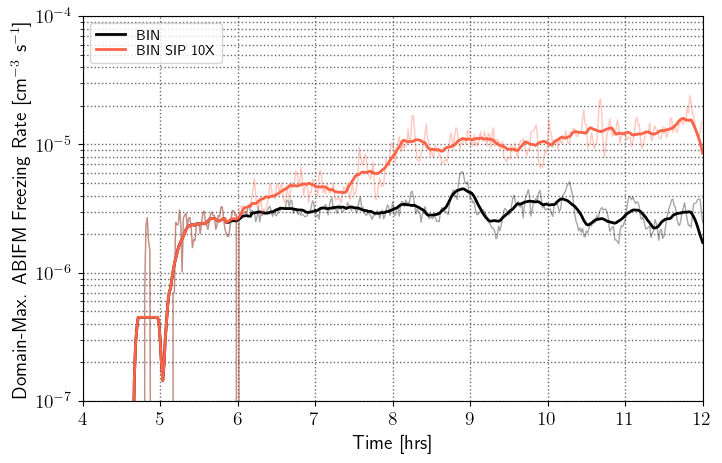

In [8]:
def running_mean(arr, window):
    kernel = np.ones(window) / window
    return np.convolve(arr, kernel, mode='same')

running_mean_window = 20

fig = plt.figure(figsize=(8,5))
ax1 = fig.add_subplot(111)
axlist = [ax1]
Fontsize=14
for ax in axlist:
    ax.grid(which='both',ls='dotted',lw=1,c='dimgrey')
    ax.tick_params(labelsize=Fontsize)
    ax.set_xlabel('Time [hrs]',fontsize=Fontsize)
    ax.set_xlim(4,12)

ax1.set_ylabel('Domain-Max. ABIFM Freezing Rate [cm$^{-3}$ s$^{-1}$]',fontsize=Fontsize)
ax1.plot(bin_dict['time']/3600.,bin_dict['max_in_imm'],alpha=0.35,lw=1,c='k')
ax1.plot(bin_dict['time']/3600.,running_mean(bin_dict['max_in_imm'],running_mean_window),lw=2,c='k',label='BIN')

ax1.plot(bin_sip_10x_dict['time']/3600.,bin_sip_10x_dict['max_in_imm'],alpha=0.35,lw=1,c='tomato')
ax1.plot(bin_sip_10x_dict['time']/3600.,running_mean(bin_sip_10x_dict['max_in_imm'],running_mean_window),lw=2,c='tomato',label='BIN SIP 10X')

ax1.legend(fontsize=Fontsize*0.75,loc='upper left',labelspacing=0.1)

ax1.set_yscale('log')
fac = 1.e-3
ax1.set_ylim(1.e-4*fac,1.e-1*fac)

plt.show()
plt.close()

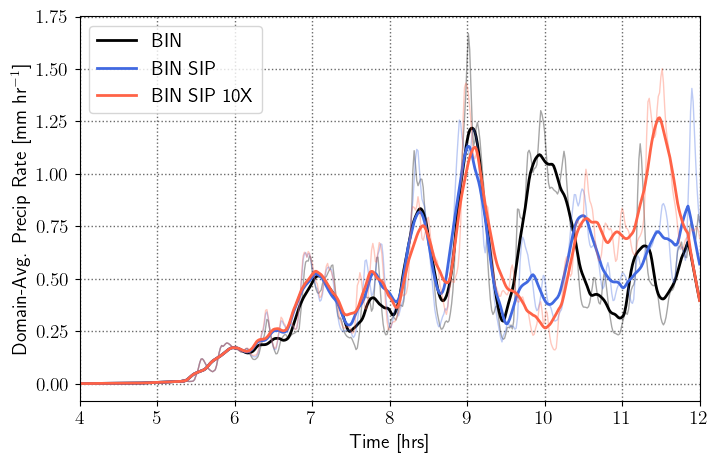

In [5]:
def running_mean(arr, window):
    kernel = np.ones(window) / window
    return np.convolve(arr, kernel, mode='same')

running_mean_window = 20

fig = plt.figure(figsize=(8,5))
ax1 = fig.add_subplot(111)
axlist = [ax1]
Fontsize=14
for ax in axlist:
    ax.grid(which='both',ls='dotted',lw=1,c='dimgrey')
    ax.tick_params(labelsize=Fontsize)
    ax.set_xlabel('Time [hrs]',fontsize=Fontsize)
    ax.set_xlim(4,12)

ax1.set_ylabel('Domain-Avg. Precip Rate [mm hr$^{-1}$]',fontsize=Fontsize)
ax1.plot(bin_dict['time']/3600.,bin_dict['avg_precip'],alpha=0.35,lw=1,c='k')
ax1.plot(bin_dict['time']/3600.,running_mean(bin_dict['avg_precip'],running_mean_window),lw=2,c='k',label='BIN')

ax1.plot(bin_sip_dict['time']/3600.,bin_sip_dict['avg_precip'],alpha=0.35,lw=1,c='royalblue')
ax1.plot(bin_sip_dict['time']/3600.,running_mean(bin_sip_dict['avg_precip'],running_mean_window),lw=2,c='royalblue',label='BIN SIP')

ax1.plot(bin_sip_10x_dict['time']/3600.,bin_sip_10x_dict['avg_precip'],alpha=0.35,lw=1,c='tomato')
ax1.plot(bin_sip_10x_dict['time']/3600.,running_mean(bin_sip_10x_dict['avg_precip'],running_mean_window),lw=2,c='tomato',label='BIN SIP 10X')

ax1.legend(fontsize=Fontsize,loc='upper left')

#ax1.set_yscale('log')
#ax1.set_ylim(1.e-4,1.e-1)

plt.show()
plt.close()

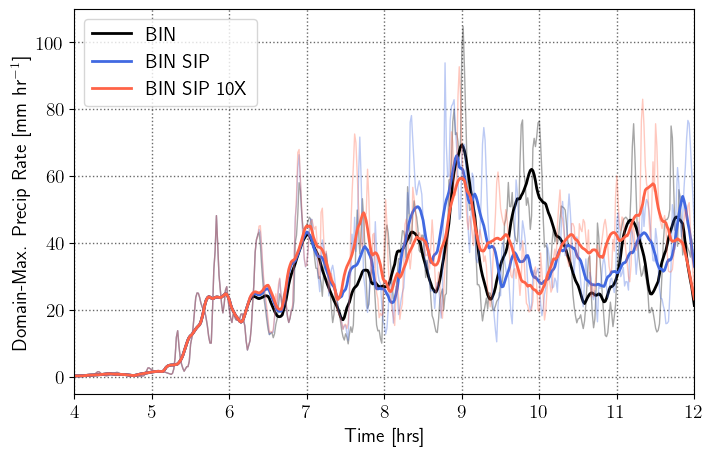

In [10]:
def running_mean(arr, window):
    kernel = np.ones(window) / window
    return np.convolve(arr, kernel, mode='same')

running_mean_window = 20

fig = plt.figure(figsize=(8,5))
ax1 = fig.add_subplot(111)
axlist = [ax1]
Fontsize=14
for ax in axlist:
    ax.grid(which='both',ls='dotted',lw=1,c='dimgrey')
    ax.tick_params(labelsize=Fontsize)
    ax.set_xlabel('Time [hrs]',fontsize=Fontsize)
    ax.set_xlim(4,12)

ax1.set_ylabel('Domain-Max. Precip Rate [mm hr$^{-1}$]',fontsize=Fontsize)
ax1.plot(bin_dict['time']/3600.,bin_dict['max_precip'],alpha=0.35,lw=1,c='k')
ax1.plot(bin_dict['time']/3600.,running_mean(bin_dict['max_precip'],running_mean_window),lw=2,c='k',label='BIN')

ax1.plot(bin_sip_dict['time']/3600.,bin_sip_dict['max_precip'],alpha=0.35,lw=1,c='royalblue')
ax1.plot(bin_sip_dict['time']/3600.,running_mean(bin_sip_dict['max_precip'],running_mean_window),lw=2,c='royalblue',label='BIN SIP')

ax1.plot(bin_sip_10x_dict['time']/3600.,bin_sip_10x_dict['max_precip'],alpha=0.35,lw=1,c='tomato')
ax1.plot(bin_sip_10x_dict['time']/3600.,running_mean(bin_sip_10x_dict['max_precip'],running_mean_window),lw=2,c='tomato',label='BIN SIP 10X')

ax1.legend(fontsize=Fontsize,loc='upper left')

#ax1.set_yscale('log')
#ax1.set_ylim(1.e-4,1.e-1)

plt.show()
plt.close()

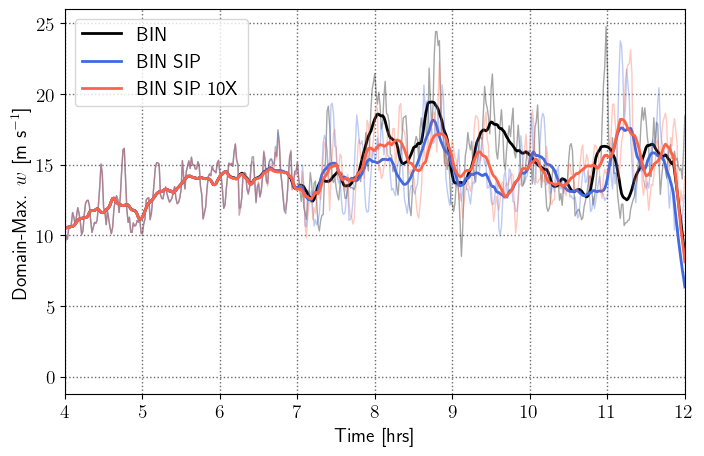

In [8]:
def running_mean(arr, window):
    kernel = np.ones(window) / window
    return np.convolve(arr, kernel, mode='same')

running_mean_window = 20

fig = plt.figure(figsize=(8,5))
ax1 = fig.add_subplot(111)
axlist = [ax1]
Fontsize=14
for ax in axlist:
    ax.grid(which='both',ls='dotted',lw=1,c='dimgrey')
    ax.tick_params(labelsize=Fontsize)
    ax.set_xlabel('Time [hrs]',fontsize=Fontsize)
    ax.set_xlim(4,12)

ax1.set_ylabel('Domain-Max. $w$ [m s$^{-1}$]',fontsize=Fontsize)
ax1.plot(bin_dict['time']/3600.,bin_dict['max_w'],alpha=0.35,lw=1,c='k')
ax1.plot(bin_dict['time']/3600.,running_mean(bin_dict['max_w'],running_mean_window),lw=2,c='k',label='BIN')

ax1.plot(bin_sip_dict['time']/3600.,bin_sip_dict['max_w'],alpha=0.35,lw=1,c='royalblue')
ax1.plot(bin_sip_dict['time']/3600.,running_mean(bin_sip_dict['max_w'],running_mean_window),lw=2,c='royalblue',label='BIN SIP')

ax1.plot(bin_sip_10x_dict['time']/3600.,bin_sip_10x_dict['max_w'],alpha=0.35,lw=1,c='tomato')
ax1.plot(bin_sip_10x_dict['time']/3600.,running_mean(bin_sip_10x_dict['max_w'],running_mean_window),lw=2,c='tomato',label='BIN SIP 10X')

ax1.legend(fontsize=Fontsize,loc='upper left')

#ax1.set_yscale('log')
#ax1.set_ylim(1.e-4,1.e-1)

plt.show()
plt.close()

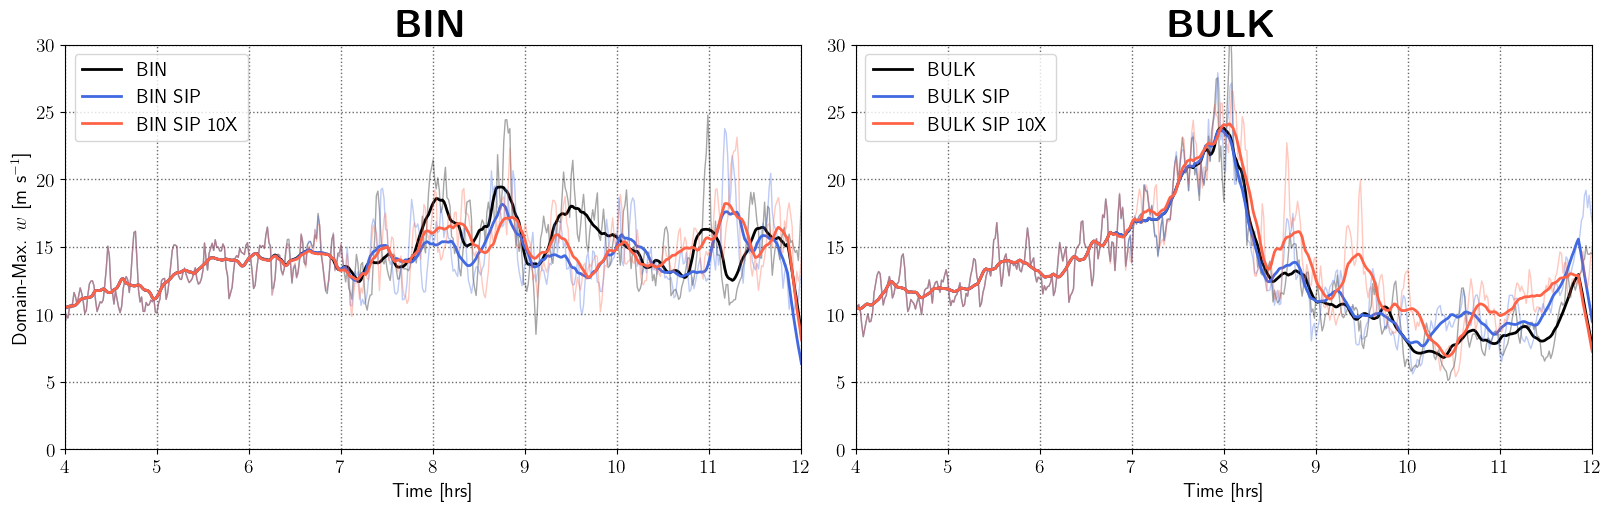

In [14]:
def running_mean(arr, window):
    kernel = np.ones(window) / window
    return np.convolve(arr, kernel, mode='same')

running_mean_window = 20

fig = plt.figure(figsize=(16,5),constrained_layout=True)
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
axlist = [ax1,ax2]
Fontsize=14
for ax in axlist:
    ax.grid(which='both',ls='dotted',lw=1,c='dimgrey')
    ax.tick_params(labelsize=Fontsize)
    ax.set_xlabel('Time [hrs]',fontsize=Fontsize)
    ax.set_xlim(4,12)
    ax.set_ylim(0,30)

ax1.set_ylabel('Domain-Max. $w$ [m s$^{-1}$]',fontsize=Fontsize)
ax1.plot(bin_dict['time']/3600.,bin_dict['max_w'],alpha=0.35,lw=1,c='k')
ax1.plot(bin_dict['time']/3600.,running_mean(bin_dict['max_w'],running_mean_window),lw=2,c='k',label='BIN')

ax1.plot(bin_sip_dict['time']/3600.,bin_sip_dict['max_w'],alpha=0.35,lw=1,c='royalblue')
ax1.plot(bin_sip_dict['time']/3600.,running_mean(bin_sip_dict['max_w'],running_mean_window),lw=2,c='royalblue',label='BIN SIP')

ax1.plot(bin_sip_10x_dict['time']/3600.,bin_sip_10x_dict['max_w'],alpha=0.35,lw=1,c='tomato')
ax1.plot(bin_sip_10x_dict['time']/3600.,running_mean(bin_sip_10x_dict['max_w'],running_mean_window),lw=2,c='tomato',label='BIN SIP 10X')

ax2.plot(bulk_dict['time']/3600.,bulk_dict['max_w'],alpha=0.35,lw=1,c='k')
ax2.plot(bulk_dict['time']/3600.,running_mean(bulk_dict['max_w'],running_mean_window),lw=2,c='k',label='BULK')

ax2.plot(bulk_sip_dict['time']/3600.,bulk_sip_dict['max_w'],alpha=0.35,lw=1,c='royalblue')
ax2.plot(bulk_sip_dict['time']/3600.,running_mean(bulk_sip_dict['max_w'],running_mean_window),lw=2,c='royalblue',label='BULK SIP')

ax2.plot(bulk_sip_10x_dict['time']/3600.,bulk_sip_10x_dict['max_w'],alpha=0.35,lw=1,c='tomato')
ax2.plot(bulk_sip_10x_dict['time']/3600.,running_mean(bulk_sip_10x_dict['max_w'],running_mean_window),lw=2,c='tomato',label='BULK SIP 10X')

ax1.legend(fontsize=Fontsize,loc='upper left')
ax2.legend(fontsize=Fontsize,loc='upper left')

#ax1.set_yscale('log')
#ax1.set_ylim(1.e-4,1.e-1)
ax1.set_title(r'\textbf{BIN}',fontsize=Fontsize*2.)
ax2.set_title(r'\textbf{BULK}',fontsize=Fontsize*2.)
plt.show()
plt.close()